In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

# from xgboost import XGBClassifier


from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
df_cardio = df_cardio = pd.read_csv("../data/cardio_train_clean.csv")
df_cardio.head(5)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,32456,23386,1,55,81.0,130,90,1,1,0,0,1,1
1,95141,18830,1,57,61.0,130,90,1,1,0,0,1,1
2,91523,18426,1,59,57.6,125,67,1,1,0,0,0,0
3,41661,19088,1,60,69.0,110,70,1,1,0,0,0,0
4,39462,20978,1,64,61.0,130,70,1,1,0,0,1,0


In [3]:
# Si prefieres que sean números enteros
df_cardio['age_years'] = (df_cardio['age'] / 365.25).astype(int)
df_cardio

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,32456,23386,1,55,81.0,130,90,1,1,0,0,1,1,64
1,95141,18830,1,57,61.0,130,90,1,1,0,0,1,1,51
2,91523,18426,1,59,57.6,125,67,1,1,0,0,0,0,50
3,41661,19088,1,60,69.0,110,70,1,1,0,0,0,0,52
4,39462,20978,1,64,61.0,130,70,1,1,0,0,1,0,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,17138,18258,2,198,102.0,110,70,1,1,0,0,1,0,49
69996,77425,21416,2,198,110.0,140,80,2,3,0,0,1,1,58
69997,59847,19187,2,200,100.0,170,1100,2,2,0,0,1,1,52
69998,30894,19054,2,207,78.0,100,70,1,1,0,1,1,0,52


### Rango de edades

In [4]:
print("Rango de edad en años:", df_cardio['age_years'].min(), "–", df_cardio['age_years'].max())

Rango de edad en años: 29 – 64


### Distribución de la variable objetivo

In [5]:
df_cardio['cardio'].value_counts(normalize=True) * 100

cardio
0    50.03
1    49.97
Name: proportion, dtype: float64

# Limpieza de datos

Primero exploraremos un poco el conjunto de datos

In [6]:
df_cardio.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700,52.803257
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003,6.762462
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,53.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.000000


## Outliers: Altura (height) y Peso (weight)

In [7]:
print("Rango de altura:", df_cardio['height'].min(), "–", df_cardio['height'].max())

Rango de altura: 55 – 250


In [8]:
print("Rango de peso", df_cardio['weight'].min(), "–", df_cardio['weight'].max())

Rango de peso 10.0 – 200.0


Calculamos el bmi. El BMI (por sus siglas en inglés, Body Mass Index) o IMC (Índice de Masa Corporal) es una medida básica que se utiliza para determinar si una persona tiene un peso saludable en relación con su estatura.

Con el bmi encontraremos valores outliers para la altura y peso

In [9]:
df_cardio['bmi'] = df_cardio['weight'] / (df_cardio['height']/100)**2
df_cardio

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
0,32456,23386,1,55,81.0,130,90,1,1,0,0,1,1,64,267.768595
1,95141,18830,1,57,61.0,130,90,1,1,0,0,1,1,51,187.750077
2,91523,18426,1,59,57.6,125,67,1,1,0,0,0,0,50,165.469693
3,41661,19088,1,60,69.0,110,70,1,1,0,0,0,0,52,191.666667
4,39462,20978,1,64,61.0,130,70,1,1,0,0,1,0,57,148.925781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,17138,18258,2,198,102.0,110,70,1,1,0,0,1,0,49,26.017753
69996,77425,21416,2,198,110.0,140,80,2,3,0,0,1,1,58,28.058361
69997,59847,19187,2,200,100.0,170,1100,2,2,0,0,1,1,52,25.000000
69998,30894,19054,2,207,78.0,100,70,1,1,0,1,1,0,52,18.203459


1. Eliminar a las personas con bmi inferiores a 15 y mayores a 70, ya que esto no es posible para un humano


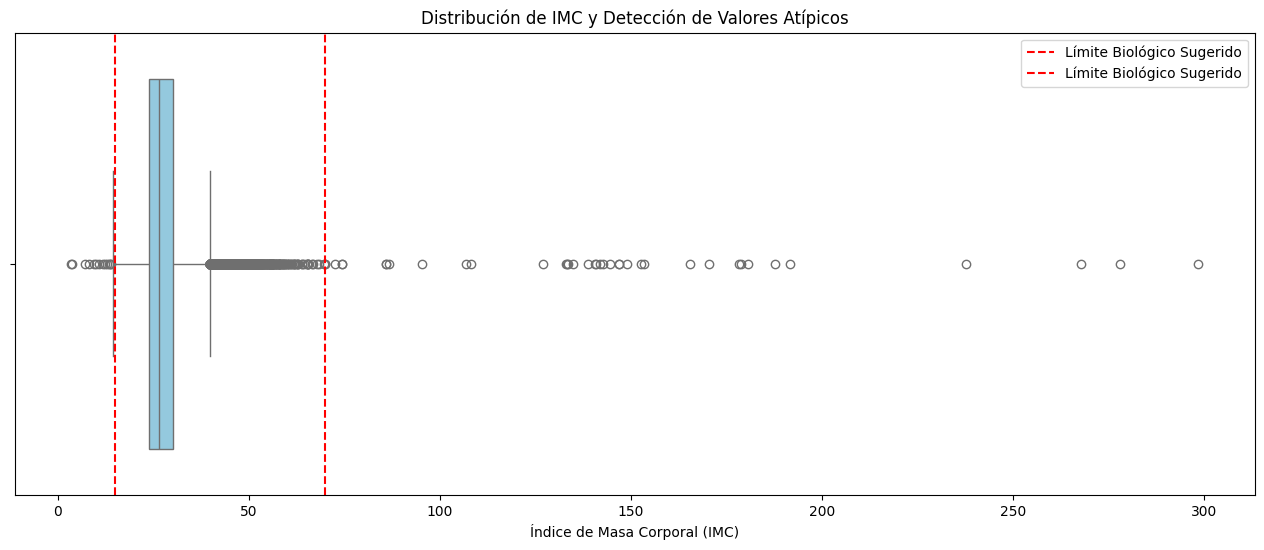

In [10]:
# Grafica
plt.figure(figsize=(16, 6))
sns.boxplot(x=df_cardio['bmi'], color='skyblue')

# Añadimos una línea roja en el límite biológico razonable (ej. 60 o 70)
plt.axvline(x=70, color='red', linestyle='--', label='Límite Biológico Sugerido')
plt.axvline(x=15, color='red', linestyle='--', label='Límite Biológico Sugerido')

plt.title('Distribución de IMC y Detección de Valores Atípicos')
plt.xlabel('Índice de Masa Corporal (IMC)')
plt.legend()
plt.show()

In [11]:
print(f"IMC menores de 15: {(df_cardio['bmi'] <= 15).sum()}")
print(f"IMC mayores de 60 cm: {(df_cardio['bmi'] >= 70).sum()}")

IMC menores de 15: 27
IMC mayores de 60 cm: 37


Eliminamos los Outlier relacionados con el bmi

In [12]:
# 2. Filtramos el dataset
df_cardio1 = df_cardio[(df_cardio['bmi'] > 15) & (df_cardio['bmi'] < 70)]

# 3. Reporte de eliminación
eliminados_bmi = len(df_cardio) - len(df_cardio1)
print(f"Se eliminaron {eliminados_bmi} registros con valores imposibles de IMC.")

Se eliminaron 64 registros con valores imposibles de IMC.


<Axes: xlabel='bmi'>

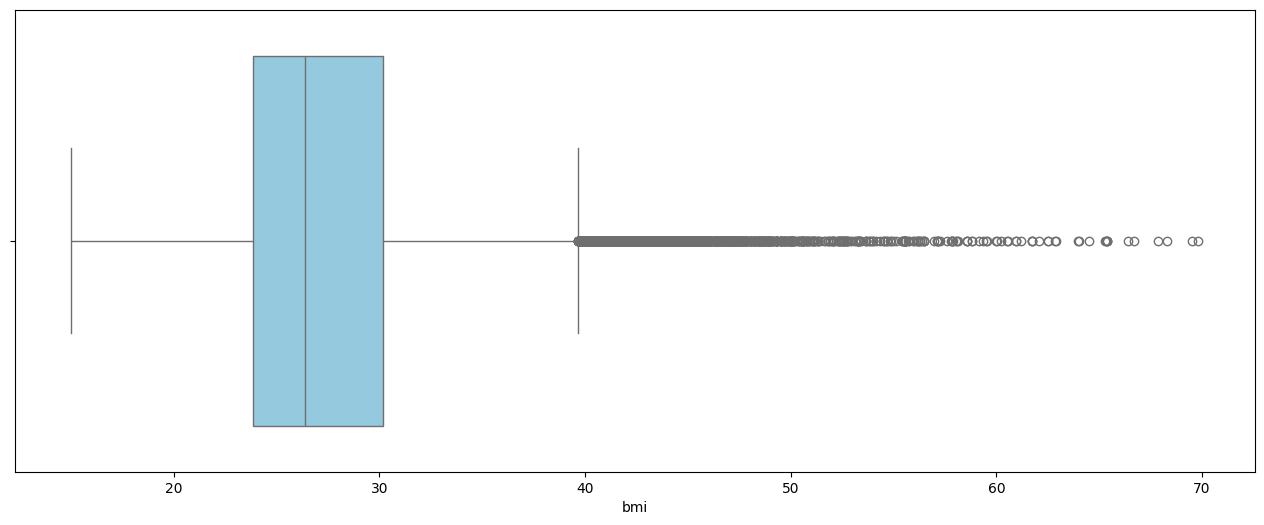

In [13]:
# Grafica
plt.figure(figsize=(16, 6))
sns.boxplot(x=df_cardio1['bmi'], color='skyblue')

Aún existe bastantes datos que podrían considerarse outliers, por eso analizaremos la altura y el peso

In [14]:
print("Rango de altura:", df_cardio1['height'].min(), "–", df_cardio1['height'].max())

Rango de altura: 91 – 207


In [15]:
print("Rango de peso", df_cardio1['weight'].min(), "–", df_cardio1['weight'].max())

Rango de peso 28.0 – 200.0


In [16]:
df_cardio1.sort_values(by='weight', ascending=True).head(5)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
91,48976,14664,2,128,28.0,120,80,1,1,0,0,1,0,40,17.089844
52,5306,15400,1,120,30.0,110,70,1,1,0,0,1,0,42,20.833333
520,50443,19802,1,146,32.0,130,80,1,2,0,0,0,0,54,15.012197
521,31439,15359,1,146,32.0,100,70,1,1,0,0,0,0,42,15.012197
251,68667,19255,1,143,33.0,100,60,1,1,0,0,1,0,52,16.137708


Como aún hay valores anómalo haremos graficas para ver los outliers de peso y altura

## Weight

Estadísticas de peso:
count    69936.000000
mean        74.207643
std         14.337398
min         28.000000
25%         65.000000
50%         72.000000
75%         82.000000
max        200.000000
Name: weight, dtype: float64

Peso menores de 30 kg: 2
Valores mayores 175 kg: 12


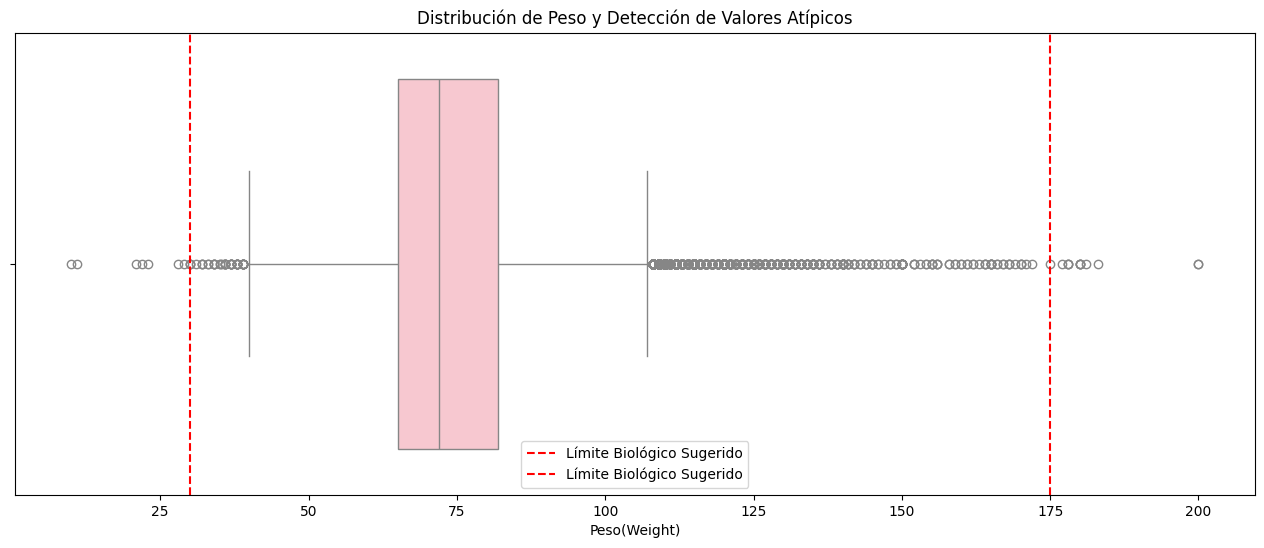

In [17]:
print("Estadísticas de peso:")
print(df_cardio1['weight'].describe())
print(f"\nPeso menores de 30 kg: {(df_cardio1['weight'] <= 30).sum()}")
print(f"Valores mayores 175 kg: {(df_cardio1['weight'] >= 175).sum()}")

# Grafica
plt.figure(figsize=(16, 6))
sns.boxplot(x=df_cardio['weight'], color='pink')

# Añadimos una línea roja en el límite biológico razonable (ej. 60 o 70)
plt.axvline(x=30, color='red', linestyle='--', label='Límite Biológico Sugerido')
plt.axvline(x=175, color='red', linestyle='--', label='Límite Biológico Sugerido')

plt.title('Distribución de Peso y Detección de Valores Atípicos')
plt.xlabel('Peso(Weight)')
plt.legend()
plt.show()

In [18]:
# 2. Filtramos el dataset
df_cardio2 = df_cardio1[(df_cardio1['weight'] > 30) & (df_cardio1['weight'] < 175)]

# 3. Reporte de eliminación
eliminados_weight = len(df_cardio1) - len(df_cardio2)
print(f"Se eliminaron {eliminados_weight} registros con valores imposibles de Peso.")

Se eliminaron 14 registros con valores imposibles de Peso.


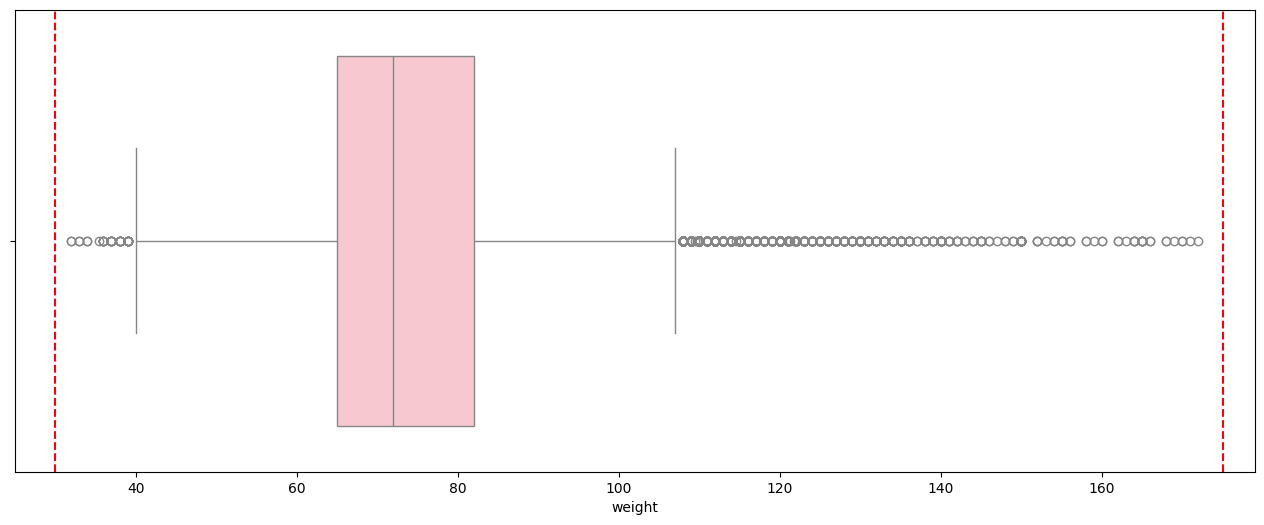

In [19]:
# Grafica
plt.figure(figsize=(16, 6))
sns.boxplot(x=df_cardio2['weight'], color='pink')
plt.axvline(x=30, color='red', linestyle='--', label='Límite Biológico Sugerido')
plt.axvline(x=175, color='red', linestyle='--', label='Límite Biológico Sugerido')

## Height

Estadísticas de peso:
count    69922.000000
mean        74.190322
std         14.265817
min         32.000000
25%         65.000000
50%         72.000000
75%         82.000000
max        172.000000
Name: weight, dtype: float64

Valores menores de 130cm: 161
Valores mayores de 200 cm: 2


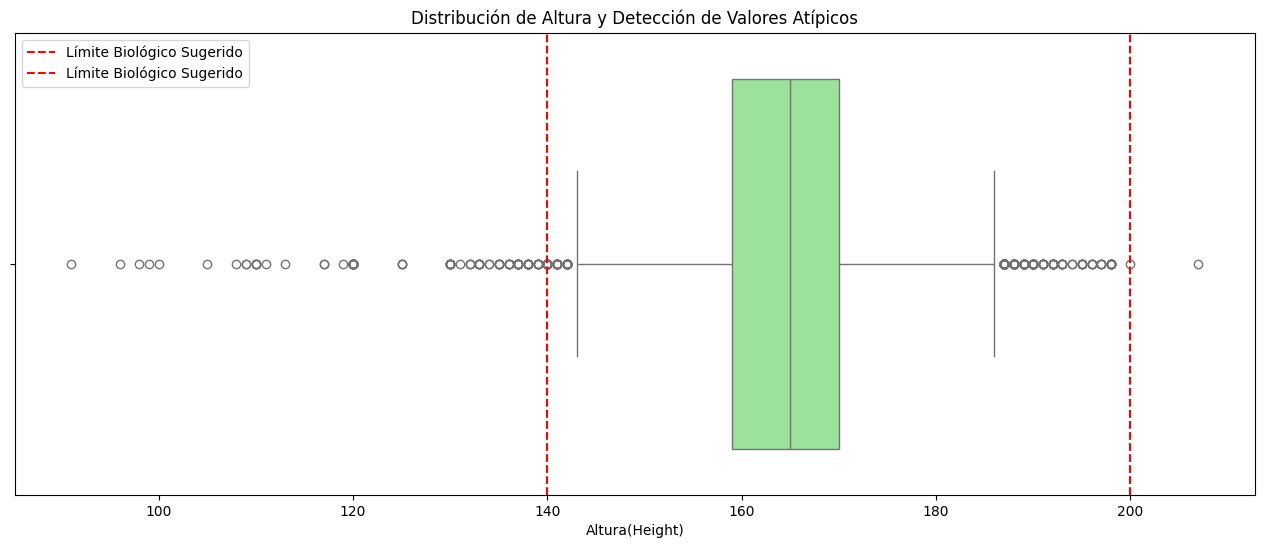

In [20]:
print("Estadísticas de peso:")
print(df_cardio2['weight'].describe())
print(f"\nValores menores de 130cm: {(df_cardio2['height'] <= 140).sum()}")
print(f"Valores mayores de 200 cm: {(df_cardio2['height'] >= 200 ).sum()}")

# Grafica
plt.figure(figsize=(16, 6))
sns.boxplot(x=df_cardio2['height'], color='lightgreen')

# Añadimos una línea roja en el límite biológico razonable (ej. 60 o 70)
plt.axvline(x=140, color='red', linestyle='--', label='Límite Biológico Sugerido')
plt.axvline(x=200, color='red', linestyle='--', label='Límite Biológico Sugerido')

plt.title('Distribución de Altura y Detección de Valores Atípicos')
plt.xlabel('Altura(Height)')
plt.legend()
plt.show()

In [21]:
# 2. Filtramos el dataset
df_cardio3 = df_cardio2[(df_cardio2['height'] > 140) & (df_cardio2['height'] < 200)]

# 3. Reporte de eliminación
eliminados_height = len(df_cardio2) - len(df_cardio3)
print(f"Se eliminaron {eliminados_height} registros con valores imposibles de Altura.")

Se eliminaron 163 registros con valores imposibles de Altura.


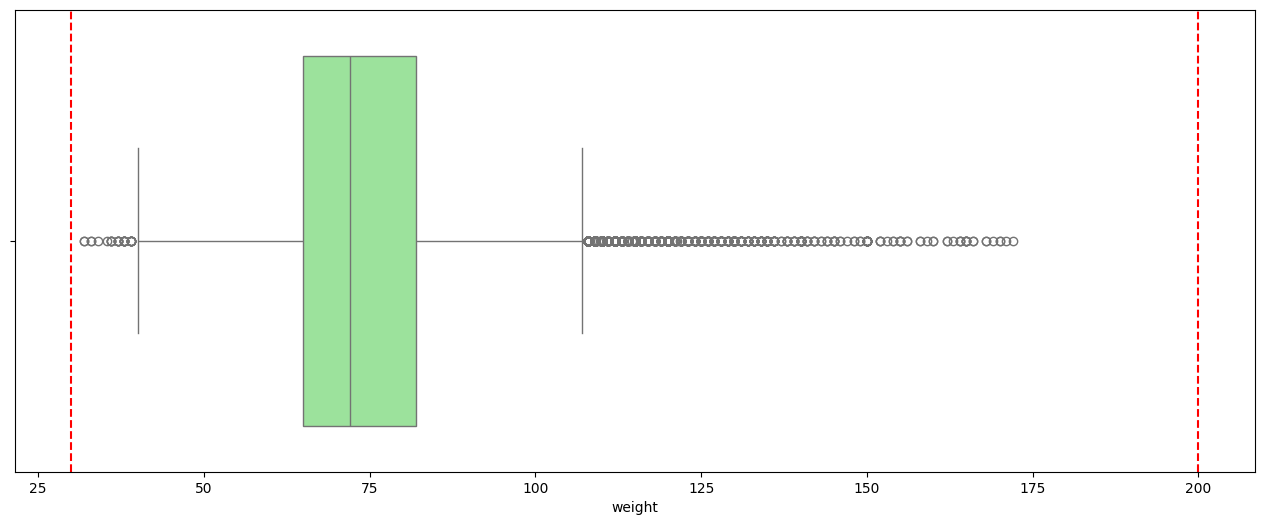

In [22]:
# Grafica
plt.figure(figsize=(16, 6))
sns.boxplot(x=df_cardio3['weight'], color='lightgreen')
plt.axvline(x=30, color='red', linestyle='--', label='Límite Biológico Sugerido')
plt.axvline(x=200, color='red', linestyle='--', label='Límite Biológico Sugerido')

# Outliers: Presión Arterial (`ap_hi` y `ap_lo`)
- Presión sistólica (`ap_hi`): rango válido 60–250 mmHg  
- Presión diastólica (`ap_lo`): rango válido 40–200 mmHg  
- Condición lógica: `ap_hi` debe ser **mayor** que `ap_lo`

**Presión Sistólica (ap_hi):** Es el valor máximo de presión. Ocurre cuando el corazón se contrae (latido) y expulsa la sangre con fuerza hacia las arterias.

**Presión Diastólica (ap_lo):** Es el valor mínimo de presión. Ocurre cuando el corazón se relaja entre un latido y el siguiente para volver a llenarse de sangre.

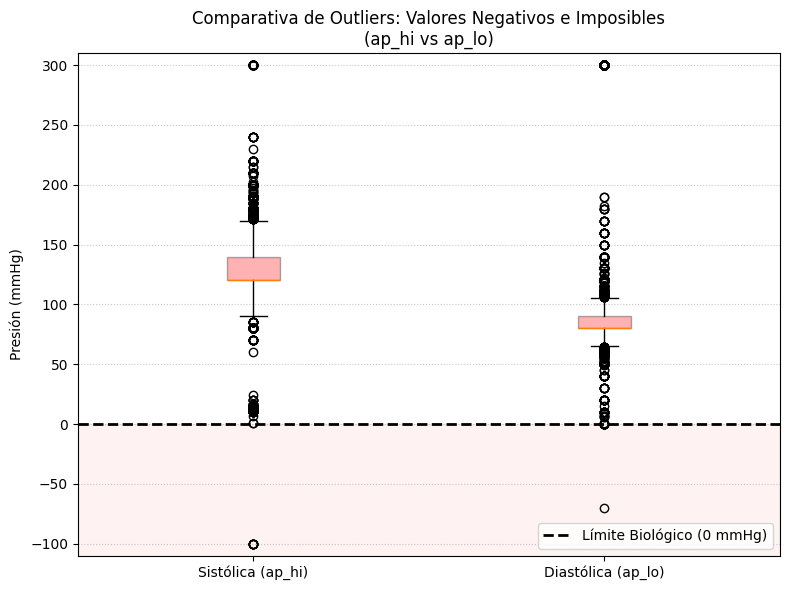

In [ ]:
# Creamos la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 1. Preparamos los datos recortados para AMBAS presiones
data_hi = df_cardio3['ap_hi'].clip(-100, 300)
data_lo = df_cardio3['ap_lo'].clip(-100, 300)

# 2. Creamos el Boxplot con las dos columnas
bp = ax.boxplot([data_hi, data_lo],
                tick_labels=['Sistólica (ap_hi)', 'Diastólica (ap_lo)'],
                patch_artist=True,
                boxprops=dict(facecolor='red', alpha=0.3))

# 3. Línea de referencia en CERO
ax.axhline(0, color='black', linestyle='--', linewidth=2, label='Límite Biológico (0 mmHg)')

# 4. Sombreado opcional para resaltar la "Zona de Error"
ax.axhspan(-110, 0, color='red', alpha=0.05)

# Configuraciones finales
ax.set_ylabel('Presión (mmHg)')
ax.set_title('Comparativa de Outliers: Valores Negativos e Imposibles\n(ap_hi vs ap_lo)', fontsize=12)
ax.set_ylim(-110, 310)
ax.grid(axis='y', linestyle=':', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

### Valores negativos

In [24]:
# 1. Eliminar valores negativos o en cero (Imposibles)
print(f"Valores menores a 0 en presión sistólica: {(df_cardio3['ap_hi'] <= 0).sum()}")
print(f"Valores menores a 0 en presión diatólica: {(df_cardio3['ap_lo'] <= 0 ).sum()}")

df_cardio4 = df_cardio3[(df_cardio3['ap_hi'] > 0) & (df_cardio3['ap_lo'] > 0)]
# Reporte de eliminación
eliminados_negativos_ap = len(df_cardio3) - len(df_cardio4)
print(f"Se eliminaron {eliminados_negativos_ap} registros con valores imposibles presión sistólica y diatólica.")

Valores menores a 0 en presión sistólica: 7
Valores menores a 0 en presión diatólica: 22
Se eliminaron 29 registros con valores imposibles presión sistólica y diatólica.


## Rangos aceptables (`ap_hi` y `ap_lo`)

### Rango mayores (`ap_hi` y `ap_lo`)

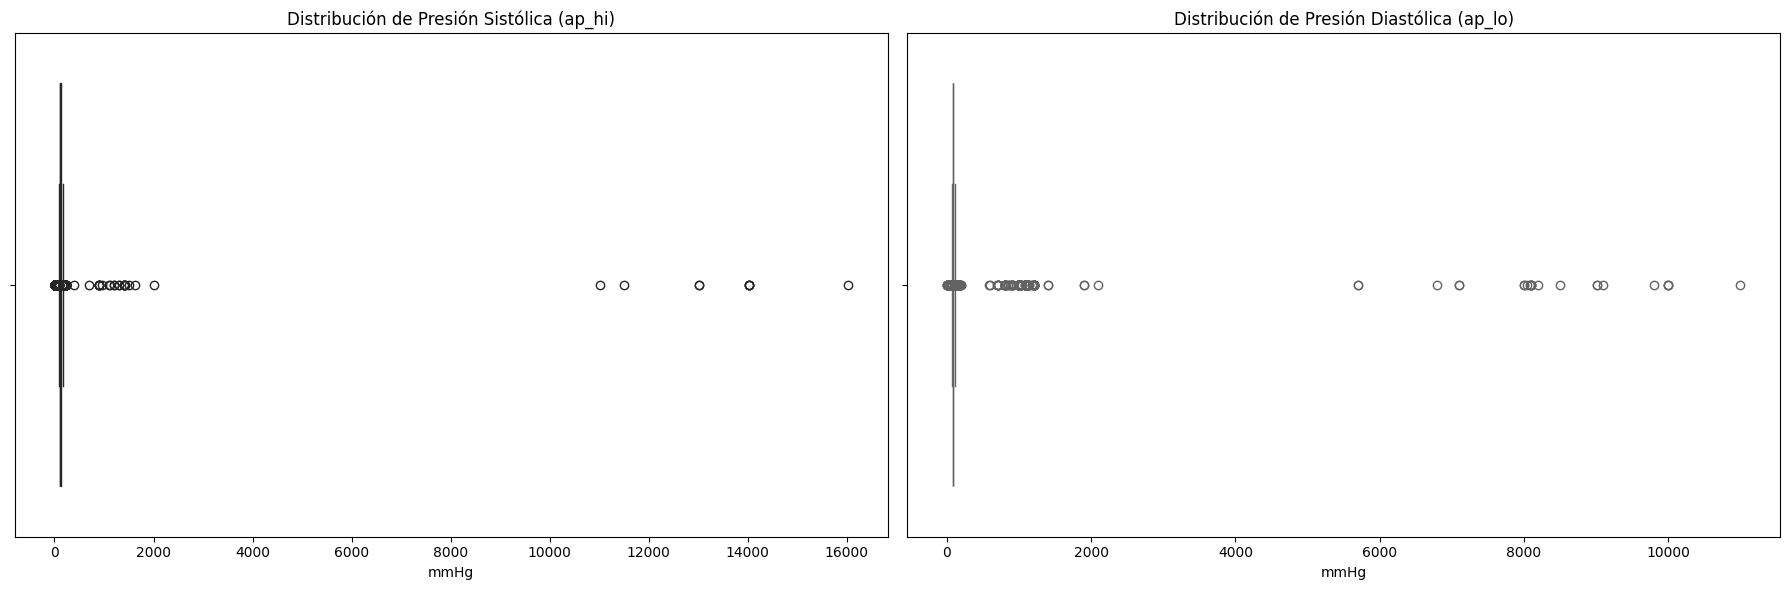

In [25]:
# Creamos una figura con 1 fila y 2 columnas
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# 1. Gráfica para ap_hi (Sistólica)
sns.boxplot(x=df_cardio4['ap_hi'], color='purple', ax=ax[0])
ax[0].set_title('Distribución de Presión Sistólica (ap_hi)')
ax[0].set_xlabel('mmHg')

# 2. Gráfica para ap_lo (Diastólica)
sns.boxplot(x=df_cardio4['ap_lo'], color='orchid', ax=ax[1]) # Cambié a orchid para diferenciar sutilmente
ax[1].set_title('Distribución de Presión Diastólica (ap_lo)')
ax[1].set_xlabel('mmHg')

# Ajustamos el diseño para que no se amontonen
plt.tight_layout()
plt.show()

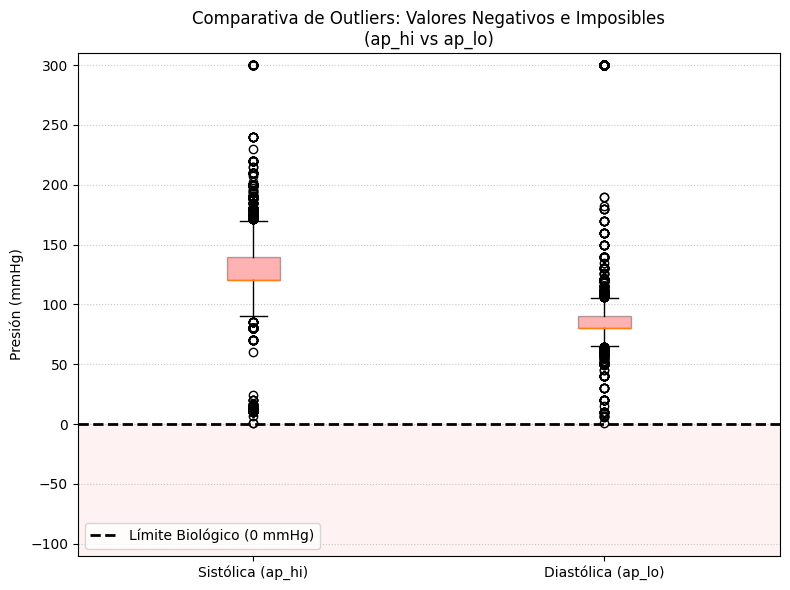

In [ ]:
# Creamos la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 1. Preparamos los datos recortados para AMBAS presiones
data_hi = df_cardio4['ap_hi'].clip(-100, 300)
data_lo = df_cardio4['ap_lo'].clip(-100, 300)

# 2. Creamos el Boxplot con las dos columnas
bp = ax.boxplot([data_hi, data_lo],
                tick_labels=['Sistólica (ap_hi)', 'Diastólica (ap_lo)'],
                patch_artist=True,
                boxprops=dict(facecolor='red', alpha=0.3))

# 3. Línea de referencia en CERO
ax.axhline(0, color='black', linestyle='--', linewidth=2, label='Límite Biológico (0 mmHg)')

# 4. Sombreado opcional para resaltar la "Zona de Error"
ax.axhspan(-110, 0, color='red', alpha=0.05)

# Configuraciones finales
ax.set_ylabel('Presión (mmHg)')
ax.set_title('Comparativa de Outliers: Valores Negativos e Imposibles\n(ap_hi vs ap_lo)', fontsize=12)
ax.set_ylim(-110, 310)
ax.grid(axis='y', linestyle=':', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

In [27]:
print(f"Valores mayores a 250 en presión sistólica: {(df_cardio4['ap_hi'] >= 250).sum()}")
print(f"Valores mayores a 200 en presión diatólica: {(df_cardio4['ap_lo'] >= 200 ).sum()}")

Valores mayores a 250 en presión sistólica: 33
Valores mayores a 200 en presión diatólica: 948


### Rangos menores (`ap_hi` y `ap_lo`)

In [28]:
print(f"Valores menores a 60 en presión sistólica: {(df_cardio4['ap_hi'] <= 60).sum()}")
print(f"Valores menores a 40 en presión diatólica: {(df_cardio4['ap_lo'] <= 40 ).sum()}")

Valores menores a 60 en presión sistólica: 177
Valores menores a 40 en presión diatólica: 52


In [29]:
# Filtrar Sistólica (ap_hi)
# Rango biológico aceptable: 60 a 250 mmHg
df_cardio5 = df_cardio4[(df_cardio4['ap_hi'] > 60) & (df_cardio4['ap_hi'] < 250)]

eliminados_ap_hi = len(df_cardio4) - len(df_cardio5)
print(f"Se eliminaron {eliminados_ap_hi} registros con valores imposibles presión sistólica (app_hi)")

Se eliminaron 210 registros con valores imposibles presión sistólica (app_hi)


In [30]:
# Filtrar Sistólica (ap_lo)
# Rango biológico aceptable: 40 a 200 mmHg
df_cardio6 = df_cardio5[(df_cardio5['ap_lo'] > 40) & (df_cardio5['ap_lo'] < 200)]

eliminados_ap_lo = len(df_cardio5) - len(df_cardio6)
print(f"Se eliminaron {eliminados_ap_lo} registros con valores imposibles presión diatólica (app_lo)")

Se eliminaron 993 registros con valores imposibles presión diatólica (app_lo)


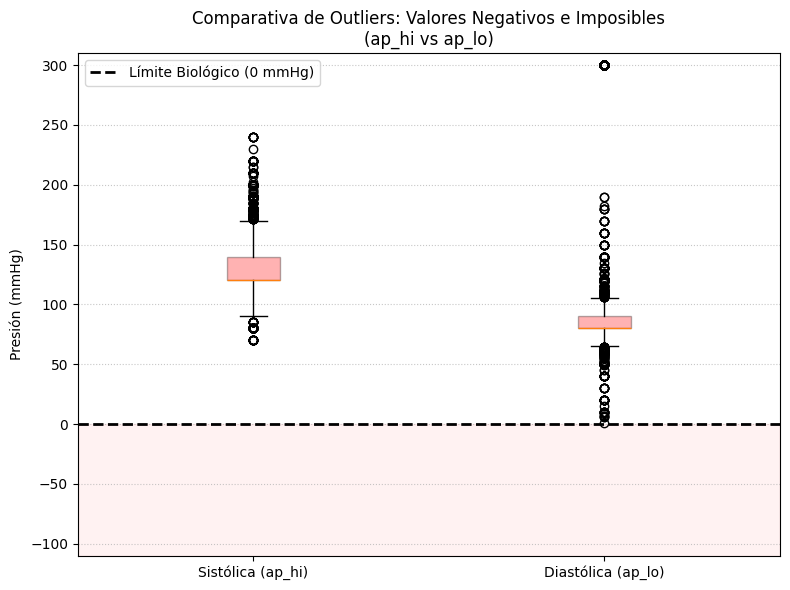

In [ ]:
# Creamos la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 1. Preparamos los datos recortados para AMBAS presiones
data_hi = df_cardio5['ap_hi'].clip(-100, 300)
data_lo = df_cardio5['ap_lo'].clip(-100, 300)

# 2. Creamos el Boxplot con las dos columnas
bp = ax.boxplot([data_hi, data_lo],
                tick_labels=['Sistólica (ap_hi)', 'Diastólica (ap_lo)'],
                patch_artist=True,
                boxprops=dict(facecolor='red', alpha=0.3))

# 3. Línea de referencia en CERO
ax.axhline(0, color='black', linestyle='--', linewidth=2, label='Límite Biológico (0 mmHg)')

# 4. Sombreado opcional para resaltar la "Zona de Error"
ax.axhspan(-110, 0, color='red', alpha=0.05)

# Configuraciones finales
ax.set_ylabel('Presión (mmHg)')
ax.set_title('Comparativa de Outliers: Valores Negativos e Imposibles\n(ap_hi vs ap_lo)', fontsize=12)
ax.set_ylim(-110, 310)
ax.grid(axis='y', linestyle=':', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

### Relación ap_hi < ap_lo – Imposible fisiológicamente
**Por qué se eliminan:** La presión sistólica (ap_hi) debe ser **siempre mayor o igual** que la diastólica (ap_lo). Si ap_hi < ap_lo, el registro es erróneo (intercambio de columnas, error de medición o de carga).

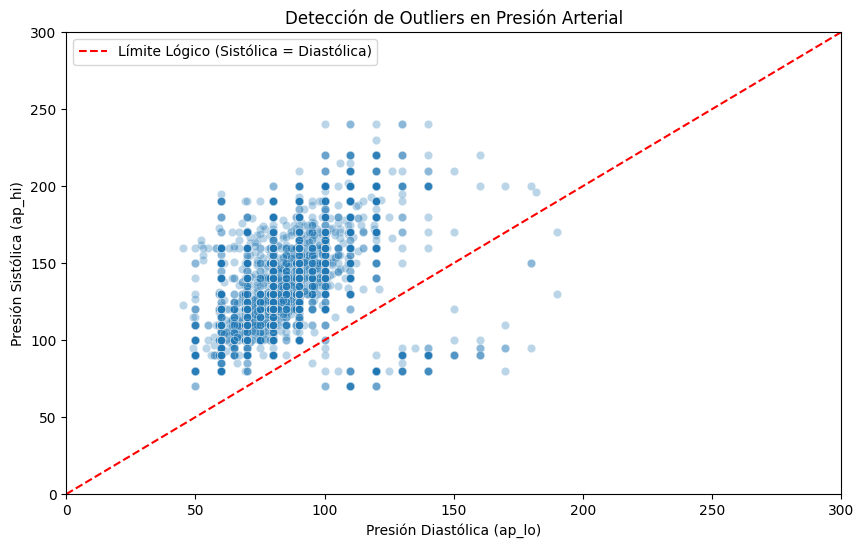

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cardio6, x='ap_lo', y='ap_hi', alpha=0.3)

# Dibujamos la "Línea de la Verdad" (donde ap_hi == ap_lo)
plt.plot([0, 300], [0, 300], color='red', linestyle='--', label='Límite Lógico (Sistólica = Diastólica)')

plt.title('Detección de Outliers en Presión Arterial')
plt.xlabel('Presión Diastólica (ap_lo)')
plt.ylabel('Presión Sistólica (ap_hi)')
plt.xlim(0, 300)
plt.ylim(0, 300)
plt.legend()
plt.show()

In [33]:
# 1. Calculamos cuántos registros violan la "Regla de Oro"
conteo_imposibles = (df_cardio6['ap_hi'] < df_cardio6['ap_lo']).sum()
print(f"Registros biológicamente imposibles (Sistólica < Diastólica): {conteo_imposibles}")

Registros biológicamente imposibles (Sistólica < Diastólica): 101


In [34]:
# La sistólica SIEMPRE debe ser mayor que la diastólica
df_cardio7 = df_cardio6[df_cardio6['ap_hi'] >= df_cardio6['ap_lo']]
eliminados_ap_im = len(df_cardio6) - len(df_cardio7)
print(f"Se eliminaron {eliminados_ap_im} registros con valores imposibles (Sistólica < Diastólica)")

Se eliminaron 101 registros con valores imposibles (Sistólica < Diastólica)


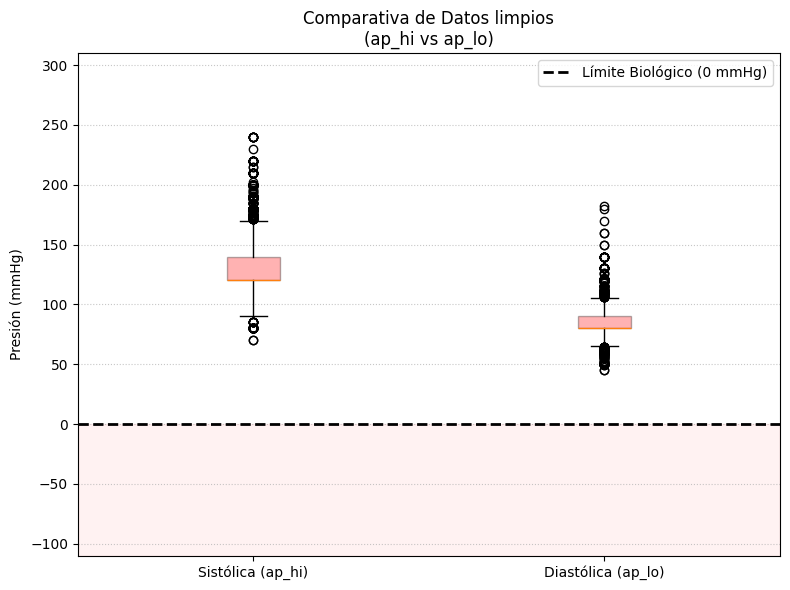

In [ ]:
# Creamos la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 1. Preparamos los datos recortados para AMBAS presiones
data_hi = df_cardio7['ap_hi'].clip(-100, 300)
data_lo = df_cardio7['ap_lo'].clip(-100, 300)

# 2. Creamos el Boxplot con las dos columnas
bp = ax.boxplot([data_hi, data_lo],
                tick_labels=['Sistólica (ap_hi)', 'Diastólica (ap_lo)'],
                patch_artist=True,
                boxprops=dict(facecolor='red', alpha=0.3))

# 3. Línea de referencia en CERO
ax.axhline(0, color='black', linestyle='--', linewidth=2, label='Límite Biológico (0 mmHg)')

# 4. Sombreado opcional para resaltar la "Zona de Error"
ax.axhspan(-110, 0, color='red', alpha=0.05)

# Configuraciones finales
ax.set_ylabel('Presión (mmHg)')
ax.set_title('Comparativa de Datos limpios\n(ap_hi vs ap_lo)', fontsize=12)
ax.set_ylim(-110, 310)
ax.grid(axis='y', linestyle=':', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

# Resumen de la limpieza

In [36]:
# === RESUMEN DE LIMPIEZA ===

df_orig = df_cardio.copy()

total_inicial = len(df_orig)
total_final = len(df_cardio7)
eliminados_totales = total_inicial - total_final
porcentaje_eliminado = (eliminados_totales / total_inicial) * 100

print("="*40)
print("       === RESUMEN DE LIMPIEZA ===")
print("="*40)
print(f"{'Criterio de eliminación':<35} {'Registros'}")
print(f"{'BMI fuera de [15, 60] (ref)':<35} {eliminados_bmi}")
print(f"{'weight fuera de [30, 200] kg':<35} {eliminados_weight}")
print(f"{'height fuera de [130, 210] cm':<35} {eliminados_height}")
print("-" * 40)
print(f"{'Valores negativos o en cero':<35} {eliminados_negativos_ap}")
print(f"{'ap_hi fuera de [70, 250] mmHg':<35} {eliminados_ap_hi}")
print(f"{'ap_lo fuera de [40, 200] mmHg':<35} {eliminados_ap_lo}")
print(f"{'ap_hi <= ap_lo (imposible)':<35} {eliminados_ap_im}")

print("\n")
print("-" * 40)
print("-" * 40)
print(f"Total registros eliminados: {eliminados_totales}")
print(f"Registros iniciales: {total_inicial}")
print(f"Registros finales (dataset limpio): {total_final}")
print(f"Porcentaje eliminado: {porcentaje_eliminado:.2f}%")
print("-" * 40)
print("\nEstadísticas descriptivas del dataset limpio:")
display(df_cardio7.describe().round(2))

       === RESUMEN DE LIMPIEZA ===
Criterio de eliminación             Registros
BMI fuera de [15, 60] (ref)         64
weight fuera de [30, 200] kg        14
height fuera de [130, 210] cm       163
----------------------------------------
Valores negativos o en cero         29
ap_hi fuera de [70, 250] mmHg       210
ap_lo fuera de [40, 200] mmHg       993
ap_hi <= ap_lo (imposible)          101


----------------------------------------
----------------------------------------
Total registros eliminados: 1574
Registros iniciales: 70000
Registros finales (dataset limpio): 68426
Porcentaje eliminado: 2.25%
----------------------------------------

Estadísticas descriptivas del dataset limpio:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
count,68426.00,68426.00,68426.00,68426.00,68426.00,68426.00,68426.00,68426.00,68426.00,68426.00,68426.00,68426.0,68426.00,68426.00,68426.00
mean,49975.93,19464.72,1.35,164.48,74.12,126.68,81.32,1.36,1.23,0.09,0.05,0.8,0.49,52.79,27.43
std,28848.33,2467.55,0.48,7.77,14.20,16.68,9.43,0.68,0.57,0.28,0.22,0.4,0.50,6.76,5.17
min,0.00,10798.00,1.00,141.00,32.00,70.00,45.00,1.00,1.00,0.00,0.00,0.0,0.00,29.00,15.01
25%,25006.25,17658.25,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.00,48.00,23.88
50%,50021.50,19701.00,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.00,53.00,26.33
75%,74868.75,21323.00,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.00,58.00,30.12
max,99999.00,23713.00,2.00,198.00,172.00,240.00,182.00,3.00,3.00,1.00,1.00,1.0,1.00,64.00,68.31


In [37]:
# Eliminamos los id
df_cardio7 = df_cardio7.drop(columns=['id'])
print('✅ Columna "id" eliminada')

✅ Columna "id" eliminada


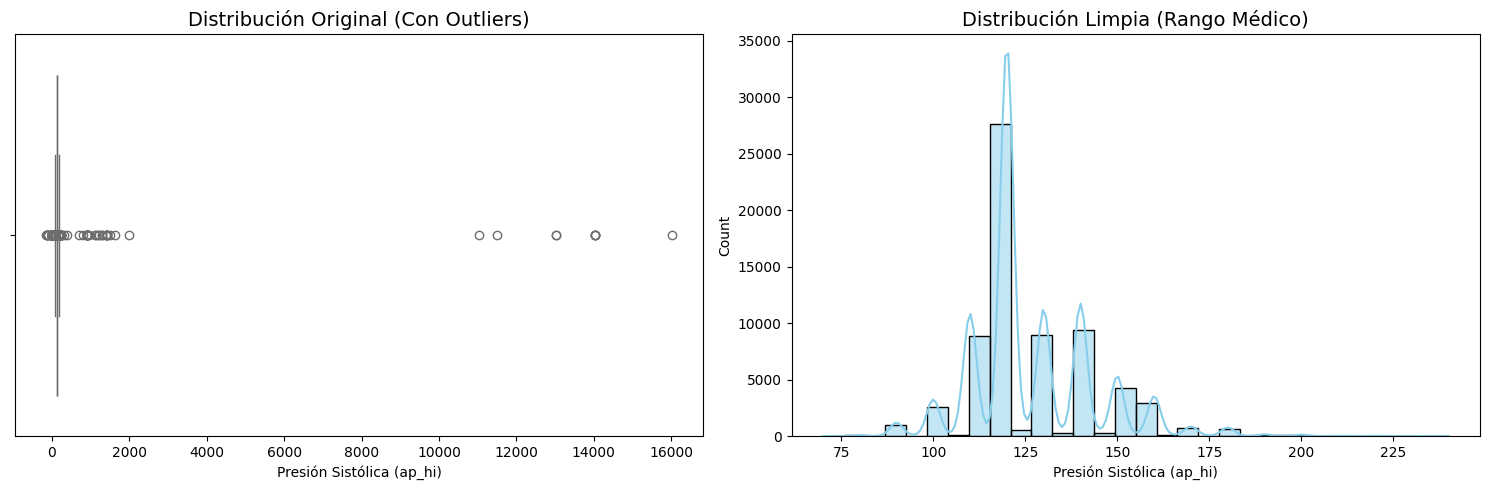

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Suponiendo que df_original es antes de limpiar y df_clean es después
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Antes de la Limpieza
sns.boxplot(x=df_cardio['ap_hi'], ax=axes[0], color='salmon')
axes[0].set_title('Distribución Original (Con Outliers)', fontsize=14)
axes[0].set_xlabel('Presión Sistólica (ap_hi)')

# 2. Después de la Limpieza
# Nota: Aquí usamos el rango normal que filtraste (ej. entre 80 y 200)
sns.histplot(df_cardio7['ap_hi'], bins=30, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Distribución Limpia (Rango Médico)', fontsize=14)
axes[1].set_xlabel('Presión Sistólica (ap_hi)')

plt.tight_layout()
plt.show()

# Análisis exploratorio de los datos

### Edad

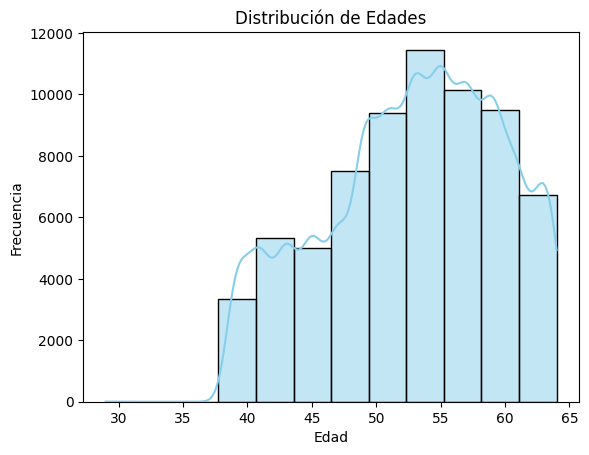

In [39]:
sns.histplot(df_cardio7['age_years'], kde=True, bins=12, color="skyblue")
plt.title('Distribución de Edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

In [40]:
print("Estadísticas de edad:")
print(df_cardio7['age_years'].describe())

Estadísticas de edad:
count    68426.000000
mean        52.791980
std          6.763185
min         29.000000
25%         48.000000
50%         53.000000
75%         58.000000
max         64.000000
Name: age_years, dtype: float64


# Relación con la variable objetivo

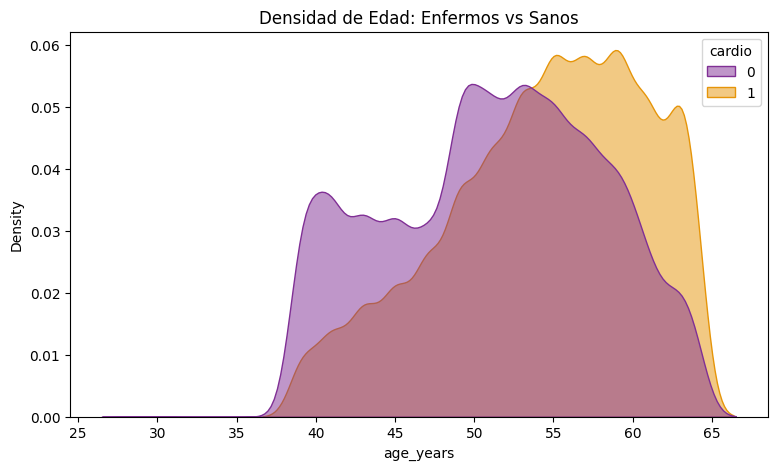

In [41]:
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df_cardio7, x='age_years', hue='cardio', fill=True, common_norm=False, palette="CMRmap", alpha=.5)
plt.title('Densidad de Edad: Enfermos vs Sanos')
plt.show()

In [42]:
# Tabla 3: Distribución de variables categóricas y binarias
tabla_categoricas = pd.DataFrame({
    'Variable': ['cardio', 'gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active'],
    'Conteo': [df_cardio7['cardio'].count()] * 7,
})
for i, col in enumerate(['cardio', 'gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']):
    counts = df_cardio7[col].value_counts().sort_index()
    tabla_categoricas.loc[i, 'Valores'] = ', '.join([f'{v}: {c}' for v, c in counts.items()])
print('=== DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS/BINARIAS ===')
display(tabla_categoricas)

# Frecuencias absolutas y relativas de la variable objetivo
print('\n=== VARIABLE OBJETIVO: cardio (enfermedad cardiovascular) ===')
cardio_dist = df_cardio7['cardio'].value_counts().sort_index()
cardio_pct = df_cardio7['cardio'].value_counts(normalize=True).sort_index() * 100
tabla_cardio = pd.DataFrame({'Frecuencia': cardio_dist, 'Porcentaje (%)': cardio_pct.round(2)})
tabla_cardio.index = ['No (0)', 'Sí (1)']
display(tabla_cardio)

=== DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS/BINARIAS ===


,Variable,Conteo,Valores
0,cardio,68426,"0: 34577, 1: 33849"
1,gender,68426,"1: 44558, 2: 23868"
2,cholesterol,68426,"1: 51315, 2: 9262, 3: 7849"
3,gluc,68426,"1: 58180, 2: 5045, 3: 5201"
4,smoke,68426,"0: 62397, 1: 6029"
5,alco,68426,"0: 64772, 1: 3654"
6,active,68426,"0: 13452, 1: 54974"



=== VARIABLE OBJETIVO: cardio (enfermedad cardiovascular) ===


,Frecuencia,Porcentaje (%)
No (0),34577,50.53
Sí (1),33849,49.47


# Feature Engineering

In [43]:
df_cardio7

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
200,20971,1,141,43.0,80,60,1,1,0,0,1,0,57,21.628691
201,22036,1,141,44.0,140,90,3,1,0,0,1,1,60,22.131684
202,17541,1,141,44.0,100,70,1,1,0,0,1,0,48,22.131684
203,21180,1,141,48.0,120,80,1,1,0,0,0,1,57,24.143655
204,22592,1,141,50.0,140,80,2,2,0,0,0,1,61,25.149640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69992,21812,2,198,90.0,130,90,1,1,0,0,1,1,59,22.956841
69993,16607,2,198,92.0,120,80,1,1,0,0,1,0,45,23.466993
69994,21201,1,198,99.0,140,80,1,1,0,0,1,1,58,25.252525
69995,18258,2,198,102.0,110,70,1,1,0,0,1,0,49,26.017753


In [44]:
df_feat = df_cardio7.copy()

# ── 5.1 IMC (Índice de Masa Corporal)
df_feat['bmi'] = (df_feat['weight'] / (df_feat['height'] / 100) ** 2).round(2)

# ── 5.2 Categoría de IMC (WHO)
def bmi_category(bmi):
    if bmi < 18.5: return 0  # Bajo peso
    elif bmi < 25: return 1  # Normal
    elif bmi < 30: return 2  # Sobrepeso
    else:          return 3  # Obesidad

df_feat['bmi_cat'] = df_feat['bmi'].apply(bmi_category)
bmi_labels = {0: 'Bajo peso', 1: 'Normal', 2: 'Sobrepeso', 3: 'Obesidad'}

print('✅ IMC y categoría IMC creados')
print(df_feat['bmi_cat'].map(bmi_labels).value_counts())

✅ IMC y categoría IMC creados
bmi_cat
Normal       25272
Sobrepeso    24683
Obesidad     17863
Bajo peso      608
Name: count, dtype: int64


In [45]:
# ── 5.3 Presión de pulso (Pulse Pressure)
# Diferencia entre presión sistólica y diastólica
# Valor elevado (>60) es factor de riesgo cardiovascular
df_feat['pulse_pressure'] = df_feat['ap_hi'] - df_feat['ap_lo']

# ── 5.4 Presión arterial media (MAP)
# Indicador del flujo sanguíneo a órganos
df_feat['map'] = ((df_feat['ap_hi'] + 2 * df_feat['ap_lo']) / 3).round(2)

print('✅ Presión de pulso y MAP creados')
print(f'   Pulse pressure | media: {df_feat["pulse_pressure"].mean():.1f} | std: {df_feat["pulse_pressure"].std():.1f}')
print(f'   MAP            | media: {df_feat["map"].mean():.1f} | std: {df_feat["map"].std():.1f}')

✅ Presión de pulso y MAP creados
   Pulse pressure | media: 45.4 | std: 11.6
   MAP            | media: 96.4 | std: 11.0


In [46]:
# ── 5.5 Clasificación de hipertensión (JNC 7)
def hypertension_stage(row):
    s, d = row['ap_hi'], row['ap_lo']
    if s < 120 and d < 80:    return 0  # Normal
    elif s < 130 and d < 80:  return 1  # Elevada
    elif s < 140 or d < 90:   return 2  # Etapa 1
    else:                      return 3  # Etapa 2 (severa)

df_feat['hypertension_stage'] = df_feat.apply(hypertension_stage, axis=1)
htn_labels = {0: 'Normal', 1: 'Elevada', 2: 'Etapa 1', 3: 'Etapa 2'}

print('✅ Etapa de hipertensión creada')
print(df_feat['hypertension_stage'].map(htn_labels).value_counts())

✅ Etapa de hipertensión creada
hypertension_stage
Etapa 1    41635
Etapa 2    14192
Normal      9506
Elevada     3093
Name: count, dtype: int64


In [47]:
# ── 5.6 Grupo etario
bins   = [0, 35, 45, 55, 65, 100]
labels = [0, 1, 2, 3, 4]  # 0:<35, 1:35-45, 2:45-55, 3:55-65, 4:>65
df_feat['age_group'] = pd.cut(df_feat['age_years'], bins=bins, labels=labels).astype(int)

age_labels = {0: '<35', 1: '35-45', 2: '45-55', 3: '55-65', 4: '>65'}
print('✅ Grupo etario creado')
print(df_feat['age_group'].map(age_labels).value_counts().sort_index())

✅ Grupo etario creado
age_group
35-45    12225
45-55    29833
55-65    26364
<35          4
Name: count, dtype: int64


In [48]:
# ── 5.7 Score de riesgo por estilo de vida
# Combina factores de riesgo modificables: fumar, alcohol, sedentarismo
df_feat['lifestyle_risk'] = (
    df_feat['smoke'] +
    df_feat['alco'] +
    (1 - df_feat['active'])  # sedentarismo como factor de riesgo
)

print('✅ Score de riesgo por estilo de vida creado (0=bajo, 3=alto)')
print(df_feat['lifestyle_risk'].value_counts().sort_index())

✅ Score de riesgo por estilo de vida creado (0=bajo, 3=alto)
lifestyle_risk
0    48382
1    17230
2     2537
3      277
Name: count, dtype: int64


In [49]:
# ── 5.8 Score metabólico
# Combina colesterol y glucosa elevados
df_feat['metabolic_score'] = df_feat['cholesterol'] + df_feat['gluc']  # rango 2–6

# ── 5.9 Interacción: colesterol elevado + hipertensión etapa 2
df_feat['chol_htn_risk'] = (
    (df_feat['cholesterol'] >= 2) & (df_feat['hypertension_stage'] >= 2)
).astype(int)

# ── 5.10 Interacción: obesidad + hipertensión
df_feat['obese_htn'] = (
    (df_feat['bmi_cat'] >= 3) & (df_feat['hypertension_stage'] >= 2)
).astype(int)

print('✅ Score metabólico e interacciones creadas')
print(f'   Pacientes con riesgo colesterol+hipertensión: {df_feat["chol_htn_risk"].sum():,}')
print(f'   Pacientes con obesidad+hipertensión: {df_feat["obese_htn"].sum():,}')

✅ Score metabólico e interacciones creadas
   Pacientes con riesgo colesterol+hipertensión: 14,901
   Pacientes con obesidad+hipertensión: 15,929


In [50]:
# ── 5.11 Resumen de nuevas features
nuevas = ['bmi', 'bmi_cat', 'pulse_pressure', 'map',
          'hypertension_stage', 'age_group',
          'lifestyle_risk', 'metabolic_score',
          'chol_htn_risk', 'obese_htn']

print(f'✅ Nuevas columnas creadas ({len(nuevas)}):')
for col in nuevas:
    print(f'   • {col}')
print(f'\nTotal de columnas ahora: {df_feat.shape[1]}')
df_feat[nuevas].describe().round(2)

✅ Nuevas columnas creadas (10):
   • bmi
   • bmi_cat
   • pulse_pressure
   • map
   • hypertension_stage
   • age_group
   • lifestyle_risk
   • metabolic_score
   • chol_htn_risk
   • obese_htn

Total de columnas ahora: 23


,bmi,bmi_cat,pulse_pressure,map,hypertension_stage,age_group,lifestyle_risk,metabolic_score,chol_htn_risk,obese_htn
count,68426.00,68426.00,68426.00,68426.00,68426.00,68426.00,68426.00,68426.00,68426.00,68426.00
mean,27.43,1.87,45.36,96.44,1.88,2.21,0.34,2.59,0.22,0.23
std,5.17,0.81,11.65,11.04,0.89,0.72,0.57,1.07,0.41,0.42
min,15.01,0.00,0.00,56.67,0.00,0.00,0.00,2.00,0.00,0.00
25%,23.88,1.00,40.00,93.33,2.00,2.00,0.00,2.00,0.00,0.00
50%,26.33,2.00,40.00,93.33,2.00,2.00,0.00,2.00,0.00,0.00
75%,30.12,3.00,50.00,103.33,2.00,3.00,1.00,3.00,0.00,0.00
max,68.31,3.00,140.00,186.67,3.00,3.00,3.00,6.00,1.00,1.00


# Análisis exploratorio post-limpieza

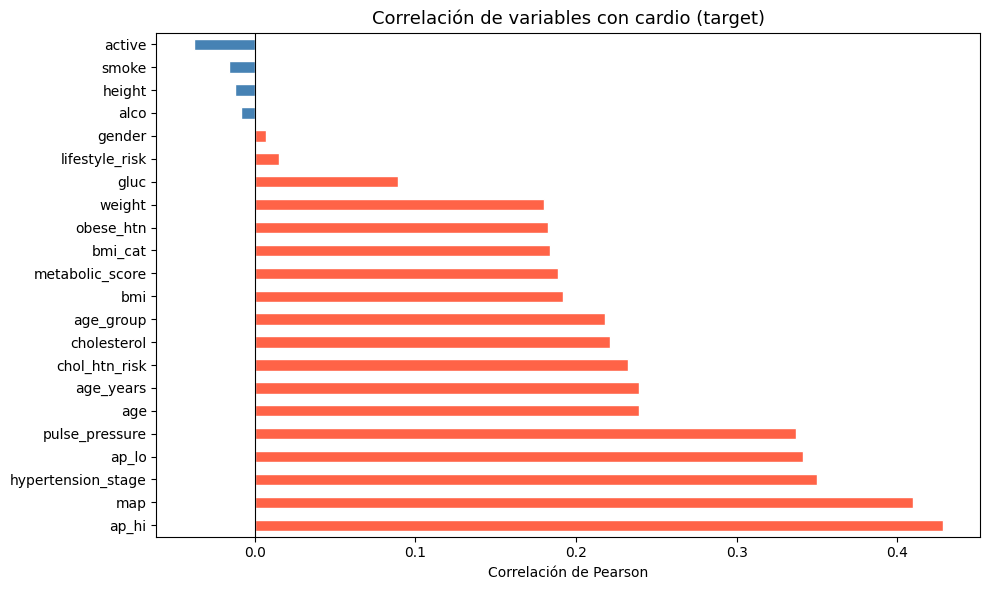


Top 5 variables más correlacionadas con cardio:
ap_hi                 0.428092
map                   0.409795
hypertension_stage    0.349627
ap_lo                 0.341044
pulse_pressure        0.337066
Name: cardio, dtype: float64


In [51]:
# Correlación con la variable objetivo
corr = df_feat.corr()['cardio'].drop('cardio').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['tomato' if x > 0 else 'steelblue' for x in corr.values]
corr.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlación de variables con cardio (target)', fontsize=13)
plt.xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()
print('\nTop 5 variables más correlacionadas con cardio:')
print(corr.head())

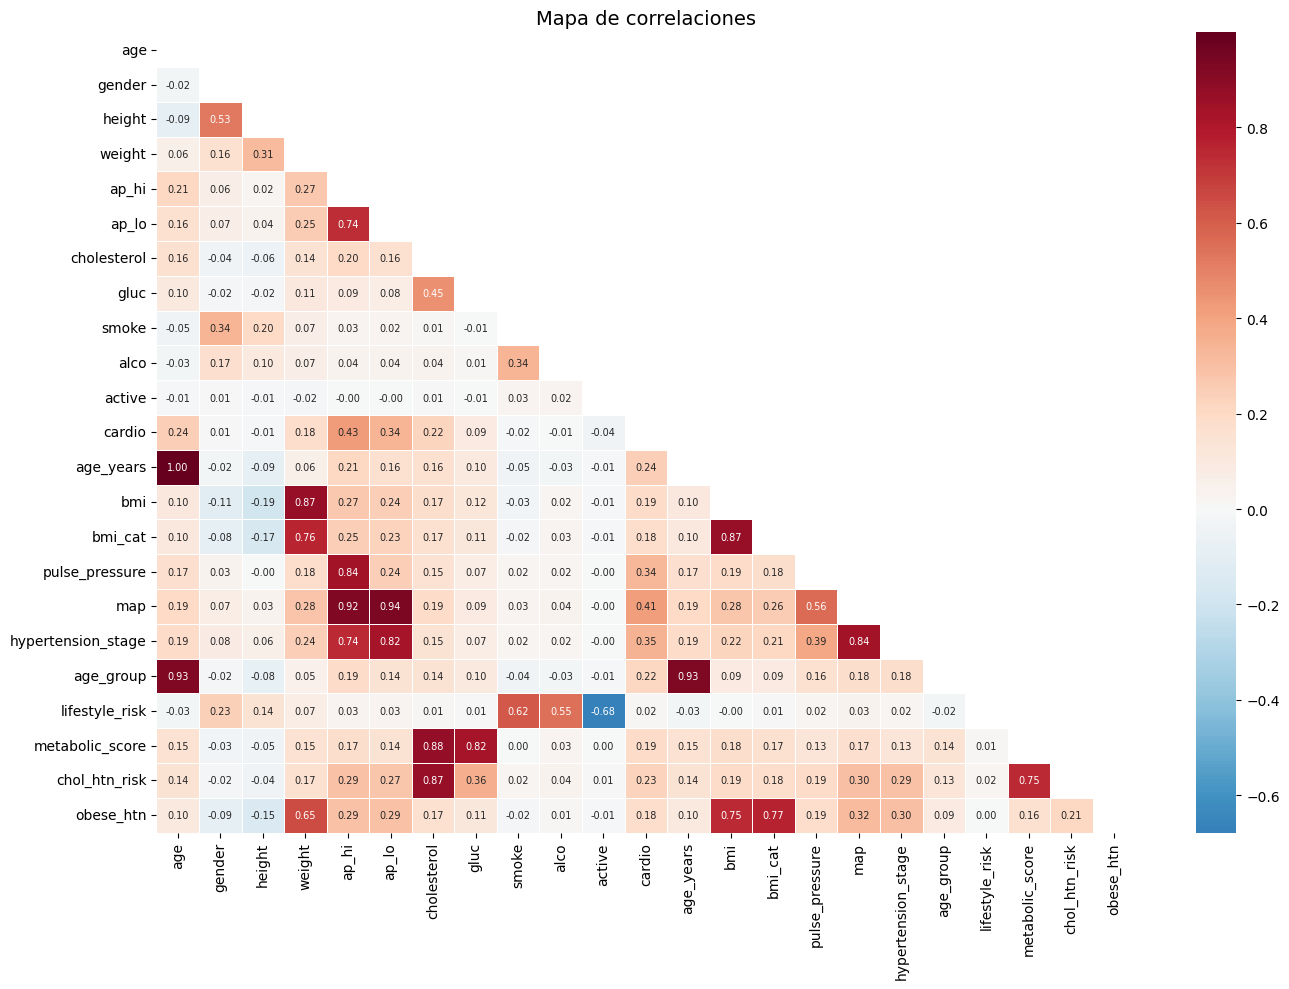

In [52]:
# Heatmap completo de correlaciones
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(df_feat.corr(), dtype=bool))
sns.heatmap(df_feat.corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, ax=ax, linewidths=0.5,
            annot_kws={'size': 7})
ax.set_title('Mapa de correlaciones', fontsize=14)
plt.tight_layout()
plt.show()

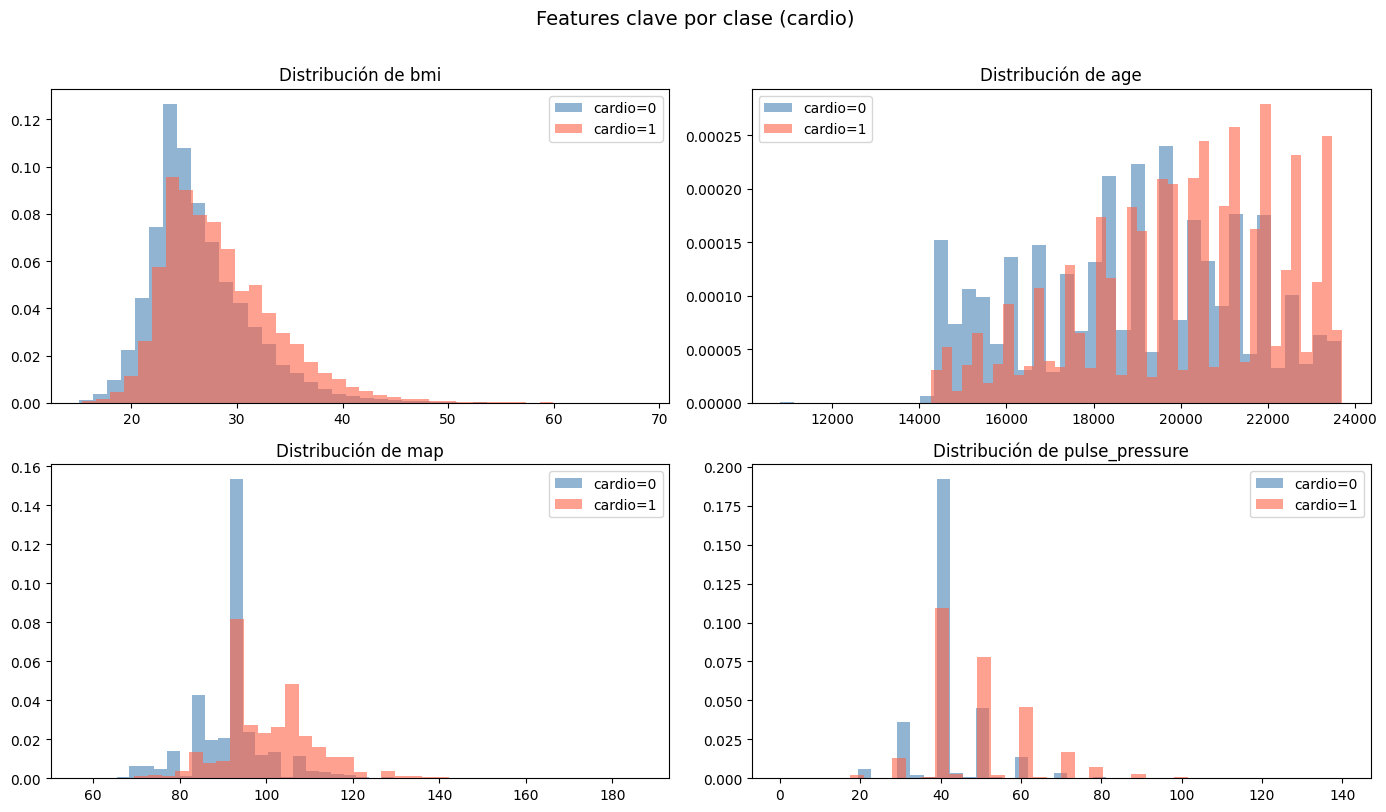

In [53]:
# Distribución de nuevas features por clase
features_plot = ['bmi', 'age', 'map', 'pulse_pressure']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(features_plot):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        axes[i].hist(df_feat[df_feat['cardio'] == label][feat],
                     bins=40, alpha=0.6, color=color,
                     label=f'cardio={label}', density=True, edgecolor='none')
    axes[i].set_title(f'Distribución de {feat}')
    axes[i].legend()

plt.suptitle('Features clave por clase (cardio)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

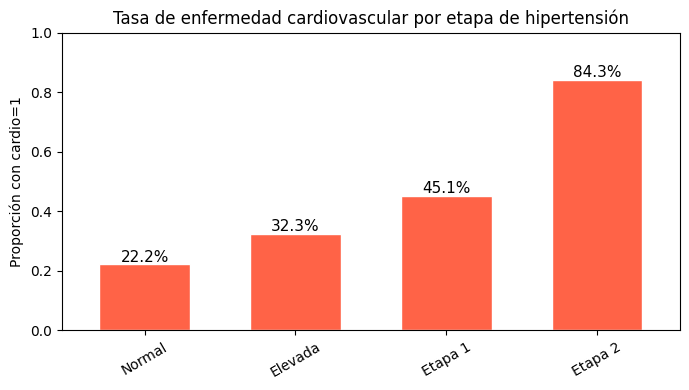

In [54]:
# Tasa de cardio por etapa de hipertensión
htn_rate = df_feat.groupby('hypertension_stage')['cardio'].mean()
htn_rate.index = [f'{htn_labels[i]}' for i in htn_rate.index]

plt.figure(figsize=(7, 4))
htn_rate.plot(kind='bar', color='tomato', edgecolor='white', width=0.6)
plt.title('Tasa de enfermedad cardiovascular por etapa de hipertensión')
plt.ylabel('Proporción con cardio=1')
plt.xticks(rotation=30)
plt.ylim(0, 1)
for i, v in enumerate(htn_rate):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# Modelado

## Modelo Clasificación

In [55]:
# ── 7.1 Separar X e y
X = df_feat.drop(columns=['cardio'])
y = df_feat['cardio']

In [56]:
# ── 7.2 Train/Test Split (80/20 estratificado)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [57]:
# -- Escalado -----------------------------------------------------------
cols_escalar = ['ap_hi', 'ap_lo', 'bmi', 'pulse_pressure', 'map', 'metabolic_score']
scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()
X_train_sc[cols_escalar] = scaler.fit_transform(X_train[cols_escalar])
X_test_sc[cols_escalar]  = scaler.transform(X_test[cols_escalar])

══════════════════════════════════════════════════
              🌲 RANDOM FOREST
══════════════════════════════════════════════════
  Accuracy  : 0.7417
  Precision : 0.7653
  Recall    : 0.6892
  F1-Score  : 0.7253
  ROC-AUC   : 0.8083
══════════════════════════════════════════════════

              precision    recall  f1-score   support

    Sano (0)       0.72      0.79      0.76      6916
 Enfermo (1)       0.77      0.69      0.73      6770

    accuracy                           0.74     13686
   macro avg       0.74      0.74      0.74     13686
weighted avg       0.74      0.74      0.74     13686



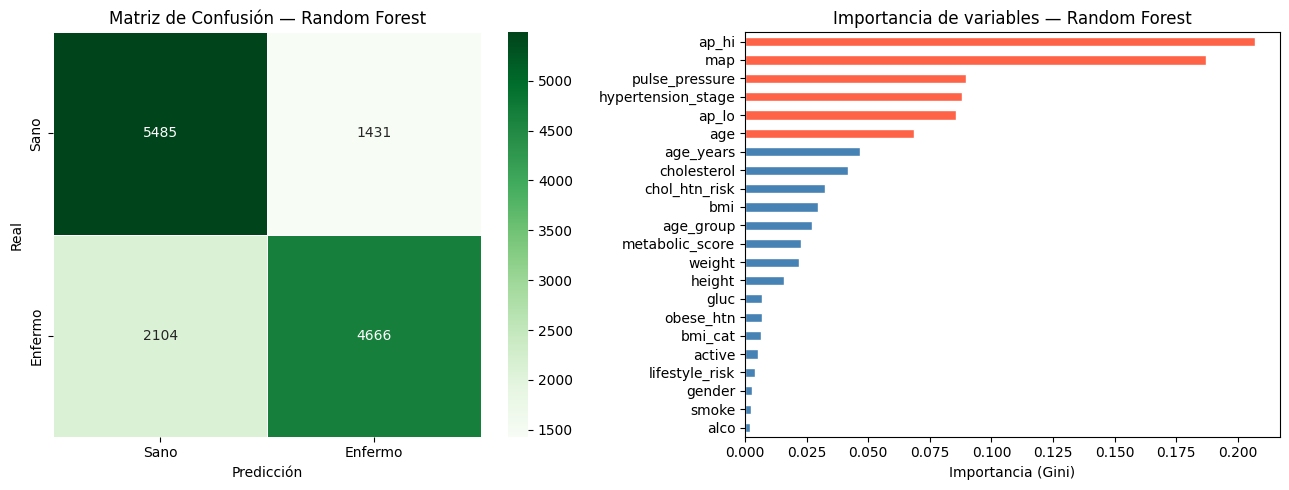

In [58]:
# ══════════════════════════════════════════════════════
#   RANDOM FOREST
# ══════════════════════════════════════════════════════
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train)

y_pred_rf  = rf.predict(X_test_sc)
y_proba_rf = rf.predict_proba(X_test_sc)[:, 1]

# ── Métricas ───────────────────────────────────────────
print('══════════════════════════════════════════════════')
print('              🌲 RANDOM FOREST')
print('══════════════════════════════════════════════════')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_rf):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_rf):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_rf):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_proba_rf):.4f}')
print('══════════════════════════════════════════════════')
print()
print(classification_report(y_test, y_pred_rf, target_names=['Sano (0)', 'Enfermo (1)']))

# ── Visualizaciones ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Sano', 'Enfermo'], yticklabels=['Sano', 'Enfermo'],
            linewidths=0.5)
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusión — Random Forest')

# Importancia de features
imp_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
colores = ['tomato' if v >= imp_rf.quantile(0.75) else 'steelblue' for v in imp_rf]
imp_rf.plot(kind='barh', ax=axes[1], color=colores, edgecolor='white')
axes[1].set_title('Importancia de variables — Random Forest')
axes[1].set_xlabel('Importancia (Gini)')

plt.tight_layout()
plt.show()

## Modelo Clustering

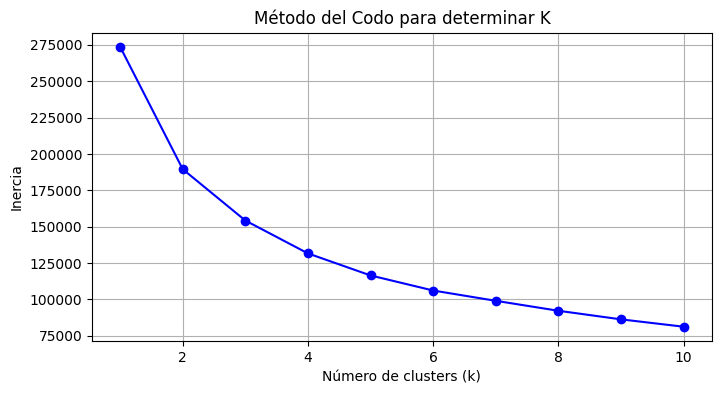

In [65]:
from sklearn.cluster import KMeans

# 1. Selección de variables para clustering
features_clustering = ['age_years', 'bmi', 'ap_hi', 'ap_lo']
X_clus = df_feat[features_clustering]

# escalar para KMeans ya que se basa en distancias
scaler_clus = StandardScaler()
X_clus_scaled = scaler_clus.fit_transform(X_clus)

# 2. Elbow Method para encontrar el número óptimo de clusters (K)
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clus_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para determinar K')
plt.grid(True)
plt.show()

Coeficiente de Silueta: 0.2449
(Un valor cercano a 1 indica clusters bien definidos; >0.20 es aceptable en salud)


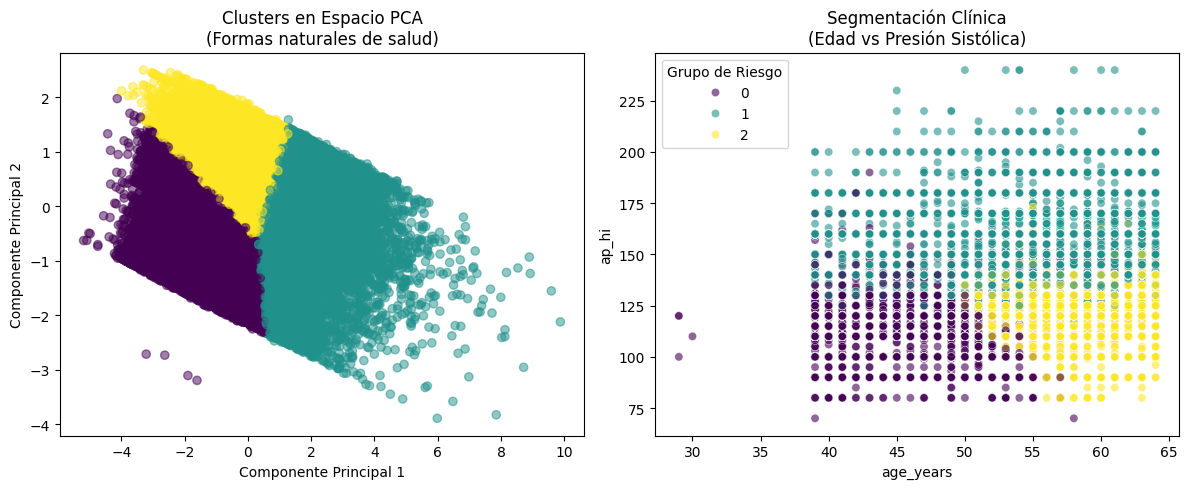

In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1. Selección estratégica de variables (sin variables que se calculen entre sí)
# Incluimos el 'metabolic_score' que creamos para darle "inteligencia" al agrupamiento
features_cluster = ['age_years', 'bmi', 'cholesterol', 'gluc', 'ap_hi', 'metabolic_score']
X_c = df_feat[features_clustering]

# 2. Escalado Robusto (Crucial para que 'ap_hi' no domine a 'age_years')
scaler_c = StandardScaler()
X_scaled = scaler_c.fit_transform(X_c)

# 3. PCA: Reducción de Dimensionalidad (Para encontrar formas naturales, no franjas)
# Reducimos a 2 componentes para visualizar la "huella digital" de salud de los pacientes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Entrenamiento con K=3 (Para mayor interpretabilidad social)
# Usamos K=3 para definir: Riesgo Bajo, Riesgo por Estilo de Vida, Riesgo Crónico
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Guardamos el cluster en el dataframe original
df_feat['cluster_mejorado'] = clusters

# 5. Evaluación Técnica (Esto suma puntos en "Resultados")
score = silhouette_score(X_scaled, clusters)
print(f"Coeficiente de Silueta: {score:.4f}")
print("(Un valor cercano a 1 indica clusters bien definidos; >0.20 es aceptable en salud)")

# ==========================================
# VISUALIZACIÓN DE ALTO NIVEL
# ==========================================
plt.figure(figsize=(12, 5))

# Gráfica 1: Espacio PCA (Donde ocurre la magia del agrupamiento)
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.5)
plt.title('Clusters en Espacio PCA\n(Formas naturales de salud)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# Gráfica 2: Realidad Clínica (Edad vs Presión con clusters nuevos)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_feat, x='age_years', y='ap_hi', hue='cluster_mejorado', palette='viridis', alpha=0.6)
plt.title('Segmentación Clínica\n(Edad vs Presión Sistólica)')
plt.legend(title='Grupo de Riesgo')

plt.tight_layout()
plt.show()

## Modelo Regresión

In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# =========================================================
# 1. INGENIERÍA DE VARIABLES (FEATURE ENGINEERING)
# =========================================================
print("--- Creando Variables de Riesgo Metabólico ---")
# Trabajamos sobre una copia para mantener intacto tu dataset original
df_model = df_feat.copy()

# Regla Médica 1: Obesidad (BMI >= 30) suma 1 punto de riesgo
df_model['risk_obesity'] = (df_model['bmi'] >= 30).astype(int)

# Regla Médica 2: Colesterol arriba de lo normal (> 1) suma 1 punto
# Asumiendo que 1=Normal, 2=Alto, 3=Muy Alto
df_model['risk_chol'] = (df_model['cholesterol'] > 1).astype(int)

# Regla Médica 3: Glucosa arriba de lo normal (> 1) suma 1 punto
df_model['risk_gluc'] = (df_model['gluc'] > 1).astype(int)

# SCORE METABÓLICO: Sumamos los riesgos fisiológicos + si fuma (rango de 0 a 4)
df_model['metabolic_score'] = df_model['risk_obesity'] + df_model['risk_chol'] + df_model['risk_gluc'] + df_model['smoke']

# =========================================================
# 2. PREPARACIÓN DE DATOS
# =========================================================
# Solo usamos variables que tendríamos ANTES de medir la presión
features = ['age_years', 'bmi', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'metabolic_score']
target = 'ap_hi'

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalado (Crítico para Ridge)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# =========================================================
# 3. ENTRENAMIENTO Y EVALUACIÓN
# =========================================================
# --- Modelo Ridge (Lineal) ---
ridge_model = Ridge(alpha=10.0) # Aumentamos alpha para mayor regularización
ridge_model.fit(X_train_sc, y_train)
y_pred_ridge = ridge_model.predict(X_test_sc)

print("\nResultados Ridge (Lineal):")
print(f"MAE: {mean_absolute_error(y_test, y_pred_ridge):.2f} mmHg")
print(f"R2:  {r2_score(y_test, y_pred_ridge):.4f}")

# --- Modelo Random Forest (No Lineal) ---
# Ajustamos hiperparámetros para evitar overfitting
rf_model = RandomForestRegressor(n_estimators=150, max_depth=8, min_samples_split=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\nResultados Random Forest (No Lineal):")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.2f} mmHg")
print(f"R2:  {r2_score(y_test, y_pred_rf):.4f}")

--- Creando Variables de Riesgo Metabólico ---

Resultados Ridge (Lineal):
MAE: 11.56 mmHg
R2:  0.1261

Resultados Random Forest (No Lineal):
MAE: 11.58 mmHg
R2:  0.1284


In [62]:
# =========================================================
# 4. ANÁLISIS DE ERRORES
# =========================================================
#  analizar dónde se equivoca el Random Forest
resultados_test = X_test.copy()
resultados_test['ap_hi_real'] = y_test
resultados_test['ap_hi_pred'] = y_pred_rf
resultados_test['error_absoluto'] = abs(resultados_test['ap_hi_real'] - resultados_test['ap_hi_pred'])

print("\n--- Análisis de Error por Segmento Médico ---")

# 1. ¿Falla más en personas con obesidad?
error_obesos = resultados_test[resultados_test['bmi'] >= 30]['error_absoluto'].mean()
error_no_obesos = resultados_test[resultados_test['bmi'] < 30]['error_absoluto'].mean()
print(f"Error promedio en pacientes CON obesidad: {error_obesos:.2f} mmHg")
print(f"Error promedio en pacientes SIN obesidad: {error_no_obesos:.2f} mmHg")

# 2. ¿Falla más en adultos mayores? (Asumiendo > 55 años)
error_mayores = resultados_test[resultados_test['age_years'] >= 55]['error_absoluto'].mean()
error_jovenes = resultados_test[resultados_test['age_years'] < 55]['error_absoluto'].mean()
print(f"\nError promedio en pacientes > 55 años: {error_mayores:.2f} mmHg")
print(f"Error promedio en pacientes < 55 años: {error_jovenes:.2f} mmHg")

# 3. Mostrar casos extremos (Casos atípicos que el modelo no pudo predecir)
print("\nTop 3 pacientes donde el modelo falló terriblemente (Outliers Fisiológicos):")
display(resultados_test.sort_values(by='error_absoluto', ascending=False).head(3)[['age_years', 'bmi', 'metabolic_score', 'ap_hi_real', 'ap_hi_pred', 'error_absoluto']])


--- Análisis de Error por Segmento Médico ---
Error promedio en pacientes CON obesidad: 13.68 mmHg
Error promedio en pacientes SIN obesidad: 10.84 mmHg

Error promedio en pacientes > 55 años: 12.27 mmHg
Error promedio en pacientes < 55 años: 11.02 mmHg

Top 3 pacientes donde el modelo falló terriblemente (Outliers Fisiológicos):


,age_years,bmi,metabolic_score,ap_hi_real,ap_hi_pred,error_absoluto
57061,54,24.28,1,220,127.135912,92.864088
61723,60,25.10,1,220,131.902256,88.097744
60351,62,24.73,2,220,132.660722,87.339278


C:\Users\edwin\AppData\Local\Temp\ipykernel_3128\2064013944.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=categorias, y=errores_mae, palette='magma')


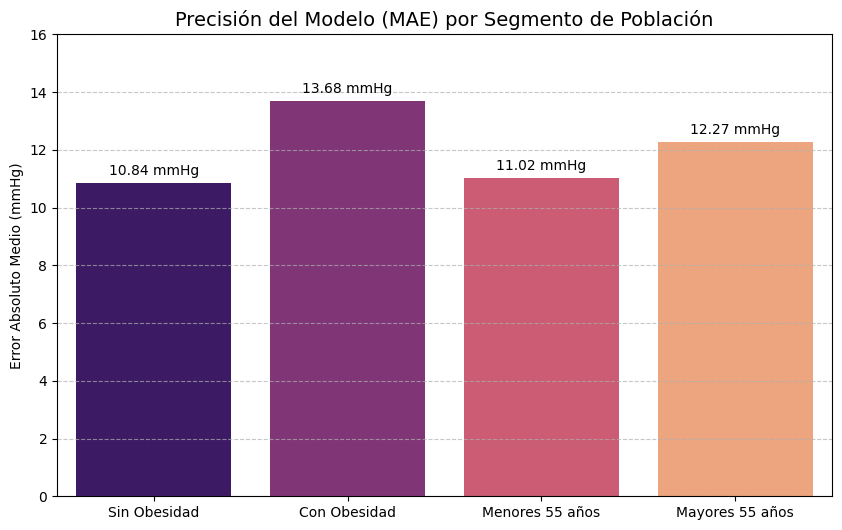

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Datos de tu análisis de errores
categorias = ['Sin Obesidad', 'Con Obesidad', 'Menores 55 años', 'Mayores 55 años']
errores_mae = [10.84, 13.68, 11.02, 12.27]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=categorias, y=errores_mae, palette='magma')

# Añadir etiquetas de datos
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f} mmHg',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.title('Precisión del Modelo (MAE) por Segmento de Población', fontsize=14)
plt.ylabel('Error Absoluto Medio (mmHg)')
plt.ylim(0, 16) # Espacio para las etiquetas
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()